In [18]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Validation
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [19]:
train_df = pd.read_csv(r"C:\Projects\House Price Prediction Project\data\raw\train.csv")
test_df = pd.read_csv(r"C:\Projects\House Price Prediction Project\data\raw\test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


In [20]:
from pandera import Column, Check, DataFrameSchema

train_schema = DataFrameSchema({
    "Id": Column(int),
    "OverallQual": Column(int, Check.in_range(1, 10)),
    "OverallCond": Column(int, Check.in_range(1, 10)),
    "GrLivArea": Column(int, Check.ge(0)),
    "GarageCars": Column(int, Check.ge(0)),
    "GarageArea": Column(int, Check.ge(0)),
    "LotArea": Column(int, Check.ge(0)),
    "SalePrice": Column(int, Check.ge(0))
})

train_schema.validate(train_df)
print("Train data validation passed!")

Train data validation passed!


In [21]:
test_df["GarageCars"] = test_df["GarageCars"].fillna(0).astype(int)
test_df["GarageArea"] = test_df["GarageArea"].fillna(0).astype(int)

In [22]:
test_schema = DataFrameSchema({
    "Id": Column(int),
    "OverallQual": Column(int, Check.in_range(1, 10)),
    "OverallCond": Column(int, Check.in_range(1, 10)),
    "GrLivArea": Column(int, Check.ge(0)),
    "GarageCars": Column(int, Check.ge(0)),
    "GarageArea": Column(int, Check.ge(0)),
    "LotArea": Column(int, Check.ge(0))
})

test_schema.validate(test_df)
print("Test data validation passed!")

Test data validation passed!


In [23]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [24]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [25]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [26]:
train_df["SalePrice"].head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

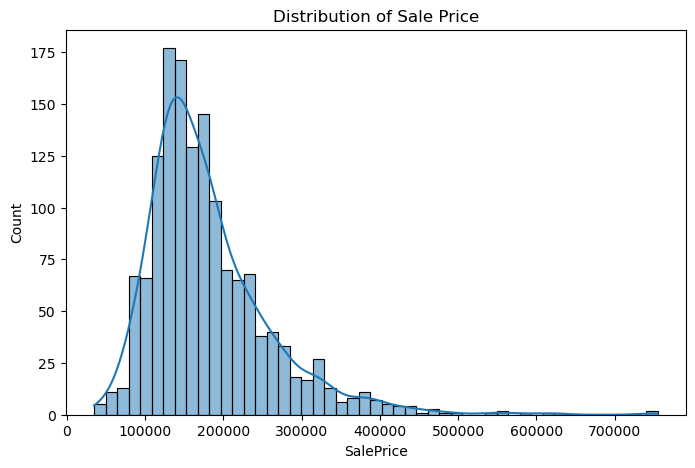

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(train_df["SalePrice"], kde=True)

plt.title("Distribution of Sale Price")
plt.show()

In [28]:
missing_values = train_df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [29]:
train_df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [30]:
print("Duplicate Rows:", train_df.duplicated().sum())

Duplicate Rows: 0


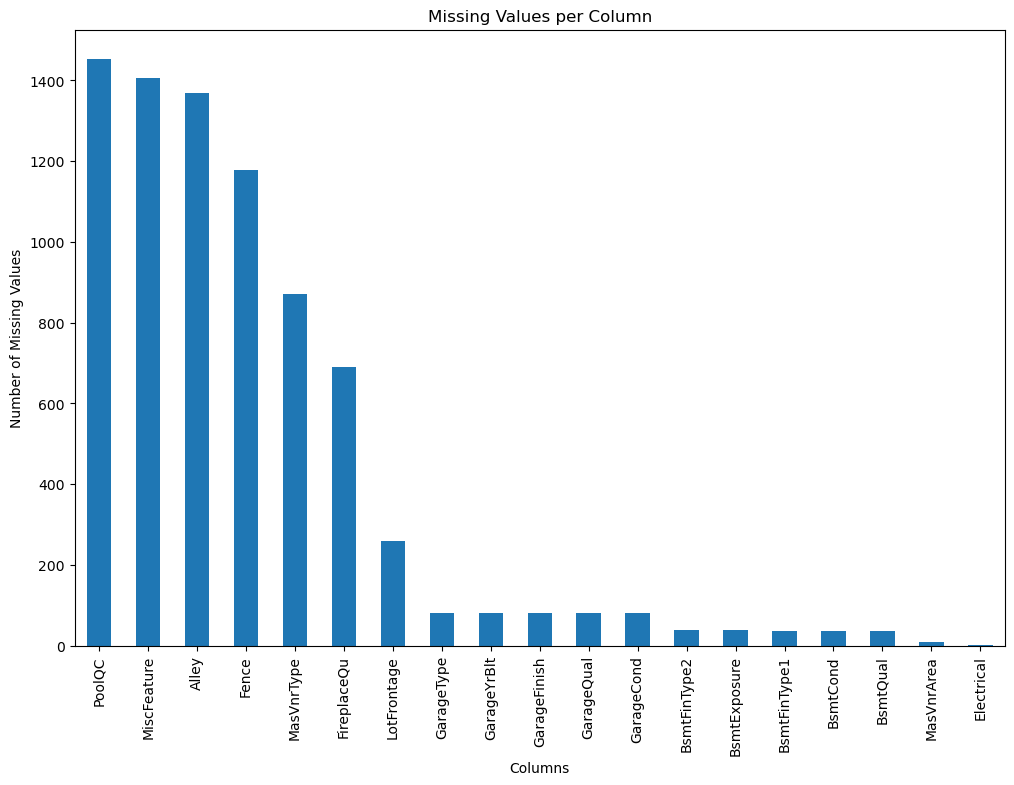

In [31]:
plt.figure(figsize=(12,8))

missing_values.plot(kind="bar")

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.show()

In [32]:
print(f"Rows    : {train_df.shape[0]}")
print(f"Columns : {train_df.shape[1]}")

Rows    : 1460
Columns : 81


In [33]:
numerical_columns = train_df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = train_df.select_dtypes(include=["object"]).columns

print("Numerical Columns :", len(numerical_columns))
print("Categorical Columns :", len(categorical_columns))

Numerical Columns : 38
Categorical Columns : 43


In [34]:
#Data Preprocessing
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

missing_percentage

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [35]:
columns_to_drop = missing_percentage[missing_percentage > 80].index.tolist()

print(columns_to_drop)

['PoolQC', 'MiscFeature', 'Alley', 'Fence']


In [36]:
train_df.drop(columns=columns_to_drop, inplace=True)
test_df.drop(columns=columns_to_drop, inplace=True)

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (1460, 77)
Test Shape  : (1459, 76)


In [37]:
train_df[train_df["GarageType"].isnull()].head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
39,40,90,RL,65.0,6040,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,6,2008,WD,AdjLand,82000
48,49,190,RM,33.0,4456,Pave,Reg,Lvl,AllPub,Inside,...,102,0,0,0,0,6,2009,New,Partial,113000
78,79,90,RL,72.0,10778,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,4,2010,WD,Normal,136500
88,89,50,C (all),105.0,8470,Pave,IR1,Lvl,AllPub,Corner,...,156,0,0,0,0,10,2009,ConLD,Abnorml,85000
89,90,20,RL,60.0,8070,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,123600


In [38]:
train_df[train_df["FireplaceQu"].isnull()].head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
5,6,50,RL,85.0,14115,Pave,IR1,Lvl,AllPub,Inside,...,0,320,0,0,700,10,2009,WD,Normal,143000
10,11,20,RL,70.0,11200,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,129500
12,13,20,RL,NaN,12968,Pave,IR2,Lvl,AllPub,Inside,...,0,0,176,0,0,9,2008,WD,Normal,144000
15,16,45,RM,51.0,6120,Pave,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,7,2007,WD,Normal,132000


In [39]:
none_fill_columns = [
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

for col in none_fill_columns:
    train_df[col] = train_df[col].fillna("None")
    test_df[col] = test_df[col].fillna("None")

In [40]:
median_fill_columns = [
    "LotFrontage",
    "GarageYrBlt",
    "MasVnrArea"
]

for col in median_fill_columns:
    median = train_df[col].median()

    train_df[col] = train_df[col].fillna(median)
    test_df[col] = test_df[col].fillna(median)

In [41]:
mode = train_df["Electrical"].mode()[0]

train_df["Electrical"] = train_df["Electrical"].fillna(mode)
test_df["Electrical"] = test_df["Electrical"].fillna(mode)

In [42]:
train_df.isnull().sum().sort_values(ascending=False).head(10)

Id              0
HalfBath        0
FireplaceQu     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
BedroomAbvGr    0
FullBath        0
dtype: int64

In [44]:
X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

In [45]:
X = pd.get_dummies(X, drop_first=True)
test_df_encoded = pd.get_dummies(test_df, drop_first=True)

In [46]:
X, test_df_encoded = X.align(
    test_df_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [47]:
print("Training Features :", X.shape)
print("Target :", y.shape)
print("Test Features :", test_df_encoded.shape)

Training Features : (1460, 247)
Target : (1460,)
Test Features : (1459, 247)


In [48]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
print("X_train :", X_train.shape)
print("X_valid :", X_valid.shape)
print("y_train :", y_train.shape)
print("y_valid :", y_valid.shape)

X_train : (1168, 247)
X_valid : (292, 247)
y_train : (1168,)
y_valid : (292,)


In [50]:
#Linear Regression
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
lr_predictions = lr_model.predict(X_valid)

In [52]:
lr_mae = mean_absolute_error(y_valid, lr_predictions)
lr_mse = mean_squared_error(y_valid, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_valid, lr_predictions)

print(f"MAE  : {lr_mae:.2f}")
print(f"MSE  : {lr_mse:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

MAE  : 20667.19
MSE  : 2759384347.01
RMSE : 52529.84
R²   : 0.6403


In [53]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [54]:
dt_predictions = dt_model.predict(X_valid)

In [55]:
dt_mae = mean_absolute_error(y_valid, dt_predictions)
dt_mse = mean_squared_error(y_valid, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_valid, dt_predictions)

print(f"MAE  : {dt_mae:.2f}")
print(f"MSE  : {dt_mse:.2f}")
print(f"RMSE : {dt_rmse:.2f}")
print(f"R²   : {dt_r2:.4f}")

MAE  : 27588.30
MSE  : 1853065417.92
RMSE : 43047.25
R²   : 0.7584


In [56]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
rf_predictions = rf_model.predict(X_valid)

In [58]:
rf_mae = mean_absolute_error(y_valid, rf_predictions)
rf_mse = mean_squared_error(y_valid, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_valid, rf_predictions)

print(f"MAE  : {rf_mae:.2f}")
print(f"MSE  : {rf_mse:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

MAE  : 17777.94
MSE  : 870960587.08
RMSE : 29512.04
R²   : 0.8865


In [59]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [60]:
xgb_predictions = xgb_model.predict(X_valid)

In [61]:
xgb_mae = mean_absolute_error(y_valid, xgb_predictions)
xgb_mse = mean_squared_error(y_valid, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_valid, xgb_predictions)

print(f"MAE  : {xgb_mae:.2f}")
print(f"MSE  : {xgb_mse:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

MAE  : 17122.47
MSE  : 746520192.00
RMSE : 27322.52
R²   : 0.9027


In [62]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

results.sort_values("R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
3,XGBoost,17122.468750,27322.521699,0.902674
2,Random Forest,17777.935274,29512.041391,0.886451
1,Decision Tree,27588.297945,43047.246345,0.758411
0,Linear Regression,20667.187714,52529.842442,0.640252


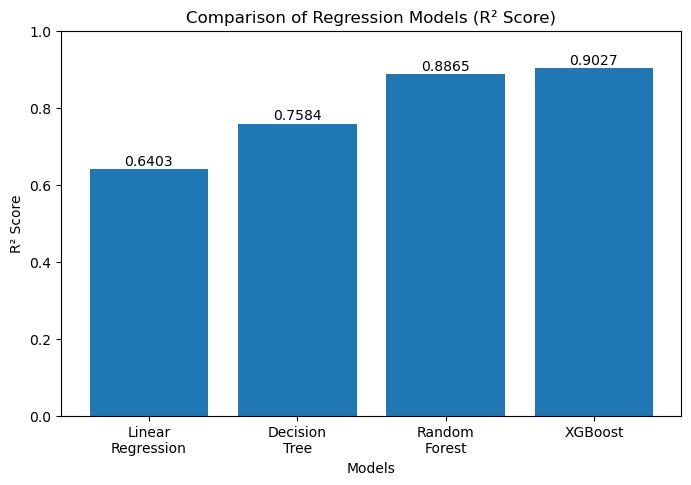

In [63]:
models = [
    "Linear\nRegression",
    "Decision\nTree",
    "Random\nForest",
    "XGBoost"
]

r2_scores = [0.6403, 0.7584, 0.8865, 0.9027]

plt.figure(figsize=(8,5))
bars = plt.bar(models, r2_scores)

plt.title("Comparison of Regression Models (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha='center',
        fontsize=10
    )

plt.show()

In [64]:
from sklearn.ensemble import StackingRegressor

In [65]:
estimators = [
    ("dt", DecisionTreeRegressor(random_state=42)),
    ("rf", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )),
    ("xgb", XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ))
]

In [66]:
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

In [ ]:
stack_model.fit(X_train, y_train)

In [ ]:
stack_predictions = stack_model.predict(X_valid)

In [ ]:
stack_mae = mean_absolute_error(y_valid, stack_predictions)
stack_mse = mean_squared_error(y_valid, stack_predictions)
stack_rmse = np.sqrt(stack_mse)
stack_r2 = r2_score(y_valid, stack_predictions)

print(f"MAE  : {stack_mae:.2f}")
print(f"MSE  : {stack_mse:.2f}")
print(f"RMSE : {stack_rmse:.2f}")
print(f"R²   : {stack_r2:.4f}")

In [ ]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

pred = cat_model.predict(X_valid)

print(r2_score(y_valid, pred))

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Linear\nRegression",
    "Decision\nTree",
    "Random\nForest",
    "XGBoost",
    "Stacking\nEnsemble",
    "CatBoost"
]

r2_scores = [0.6403, 0.7584, 0.8865, 0.9027, 0.9007, 0.9058]

plt.figure(figsize=(10,6))

bars = plt.bar(models, r2_scores)

plt.title("Comparison of Regression Models", fontsize=16, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0.5, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Linear\nRegression",
    "Decision\nTree",
    "Random\nForest",
    "XGBoost",
    "Stacking\nEnsemble",
    "CatBoost"
]

rmse_scores = [
    52529.84,
    43047.25,
    29512.04,
    27322.52,
    27593.12,
    26902.16   # <-- Replace with your actual CatBoost RMSE if different
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, rmse_scores)

plt.title("Comparison of Regression Models (RMSE)", fontsize=16, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("RMSE", fontsize=12)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+500,
        f"{bar.get_height():.0f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from catboost import CatBoostRegressor

final_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

final_model.fit(X, y)

In [ ]:
test_predictions = final_model.predict(test_df_encoded)

In [ ]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_predictions
})

submission.head()

In [ ]:
submission.to_csv("submission.csv", index=False)